# Single Match Analysis - Final Match




## 0. Setup - Imports and Configuration

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import config
from src.analysis.game_utils import game_summary
from src.analysis.prediction_utils import normalize_predictions, print_top_predictions, visualize_top_possessions, \
    create_top_possessions_df
from src.data.data_loader import load_socceraction_match
from src.ml.models.model_factory import load_model
from src.ml.preprocessing.sequence import SequencePreprocessor, PreprocessingMode
from src.ml.xthreat import get_default_xt_model


In [2]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [3]:
match_id = 3943043
selected_match, selected_events = load_socceraction_match("data/statsbomb/data", 55, 282, match_id)

print(f"Loaded match: {game_summary(selected_match)} with {len(selected_events)} events")

Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loaded match: Spain 2 : 1 England (Final) [14.07.2024] with 3312 events


## 2. Load Trained Model

In [4]:
# Load the best trained model
MODEL_TYPE = 'attention_lstm'
model = load_model(MODEL_TYPE)
print(f"Model type: {MODEL_TYPE}")


Model type: attention_lstm


In [5]:
# Display model architecture
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 6, 46)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 256)         │       179,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_weights               │ [(None, 128), (None,   │           134 │
│ (AttentionLayer)                │ 6)]                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ value (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,154,327 (4.40 MB)

 Trainable params: 384,775 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 769,552 (2.94 MB)

## 3. Preprocess Data for Analysis

In [19]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p = preprocessor.process_match(match_id, selected_match, selected_events, mode=PreprocessingMode.TRAINING)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events (mode: training)
 → Generated 1301 sequences, 1301 labels for match 3943043
Validation set preprocessed: 1301 sequences


In [7]:
X.shape

(124, 6, 46)

In [8]:
p.shape

(124,)

In [9]:
p[0:200]

array([  2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  15,
        16,  17,  19,  21,  22,  24,  25,  26,  27,  28,  29,  30,  31,
        32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,
        46,  47,  48,  49,  50,  51,  52,  53,  54,  56,  58,  59,  60,
        61,  62,  63,  64,  65,  66,  67,  69,  71,  73,  74,  75,  77,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 117, 119, 120,
       121, 122, 123, 124, 125, 127, 128, 129, 130, 131, 132, 133, 134,
       135, 136, 137, 138, 142, 144, 146])

## 4. Analysis


#### Make predictions on match sequences

In [16]:
predictions = model.predict(X, batch_size=32, verbose=0)
predictions

{'value': array([[0.0315219 ],
        [0.0115834 ],
        [0.01275667],
        ...,
        [0.02559845],
        [0.01353634],
        [0.02144041]], dtype=float32),
 'attention_weights': array([[0.10421646, 0.10090752, 0.11229526, 0.14540061, 0.28654978,
         0.2506304 ],
        [0.12989563, 0.12473743, 0.12696967, 0.1572784 , 0.2202027 ,
         0.24091615],
        [0.13065737, 0.12030376, 0.13184421, 0.14595012, 0.24572293,
         0.22552167],
        ...,
        [0.11412593, 0.11551161, 0.11211744, 0.16079739, 0.27397496,
         0.22347265],
        [0.13212648, 0.126513  , 0.13589081, 0.17294712, 0.24635495,
         0.18616766],
        [0.14148898, 0.13117516, 0.13449678, 0.15007776, 0.22580288,
         0.21695837]], dtype=float32)}

#### Predictions

In [18]:
predicted_values_final, attention_weights_final = normalize_predictions(predictions)
print(f"Total sequences analyzed: {len(predicted_values_final)}")
print(f"Sum of all predicted values: {predicted_values_final.sum():.3f}")
print(f"Has attention weights: {attention_weights_final is not None}")

Total sequences analyzed: 1301
Sum of all predicted values: 37.924
Has attention weights: True


#### LSTM Attention Weights and Predicted Values

#### Get top 8 sequences by predicted value

In [20]:
number_of_top_predictions = 8
print_top_predictions(predicted_values_final, p, None, number_of_top_predictions, attention_weights_final)


Top 8 sequences with highest predicted values:

1. Possession id = 138: Value = 0.332
   Attention weights: ['0.163', '0.143', '0.148', '0.191', '0.214', '0.141']
   Most important action: position 4 (weight: 0.214)

2. Possession id = 92: Value = 0.332
   Attention weights: ['0.180', '0.145', '0.155', '0.161', '0.178', '0.181']
   Most important action: position 5 (weight: 0.181)

3. Possession id = 136: Value = 0.299
   Attention weights: ['0.205', '0.179', '0.163', '0.170', '0.162', '0.122']
   Most important action: position 0 (weight: 0.205)

4. Possession id = 123: Value = 0.283
   Attention weights: ['0.200', '0.148', '0.163', '0.173', '0.190', '0.126']
   Most important action: position 0 (weight: 0.200)

5. Possession id = 110: Value = 0.281
   Attention weights: ['0.199', '0.183', '0.171', '0.163', '0.157', '0.126']
   Most important action: position 0 (weight: 0.199)

6. Possession id = 9: Value = 0.277
   Attention weights: ['0.195', '0.151', '0.150', '0.172', '0.194', '0.

#### Top possessions information

In [21]:
top_possessions_df = create_top_possessions_df(selected_match, selected_events, p, predicted_values_final, attention_weights_final, 50)
top_possessions_df.to_csv(f"models/{MODEL_TYPE}/top_possessions_final_df.csv", index=False)
top_possessions_df.head()

,possession_id,value,attention_weights,game_id,team_id,team_name,period,time_start,time_end,outcome
0,138,0.332363,"[0.16318074, 0.14258035, 0.14832829, 0.19074854, 0.21441098, 0.14075123]",3943043,768,England,2,5352,5357,Shot
1,92,0.331538,"[0.18041322, 0.14469658, 0.15457103, 0.16086437, 0.17803115, 0.1814237]",3943043,772,Spain,2,3267,3323,Shot
2,136,0.298937,"[0.2046728, 0.17864235, 0.16313072, 0.16986793, 0.16159075, 0.122095406]",3943043,772,Spain,2,5143,5156,Goal
3,123,0.282744,"[0.20026481, 0.14770141, 0.163083, 0.17267518, 0.18985885, 0.12641673]",3943043,772,Spain,2,4541,4660,Pass
4,110,0.280726,"[0.19914609, 0.18334042, 0.17102161, 0.16312984, 0.15703964, 0.12632248]",3943043,772,Spain,2,4123,4147,Shot


#### Visualize top 8 possessions on the pitch

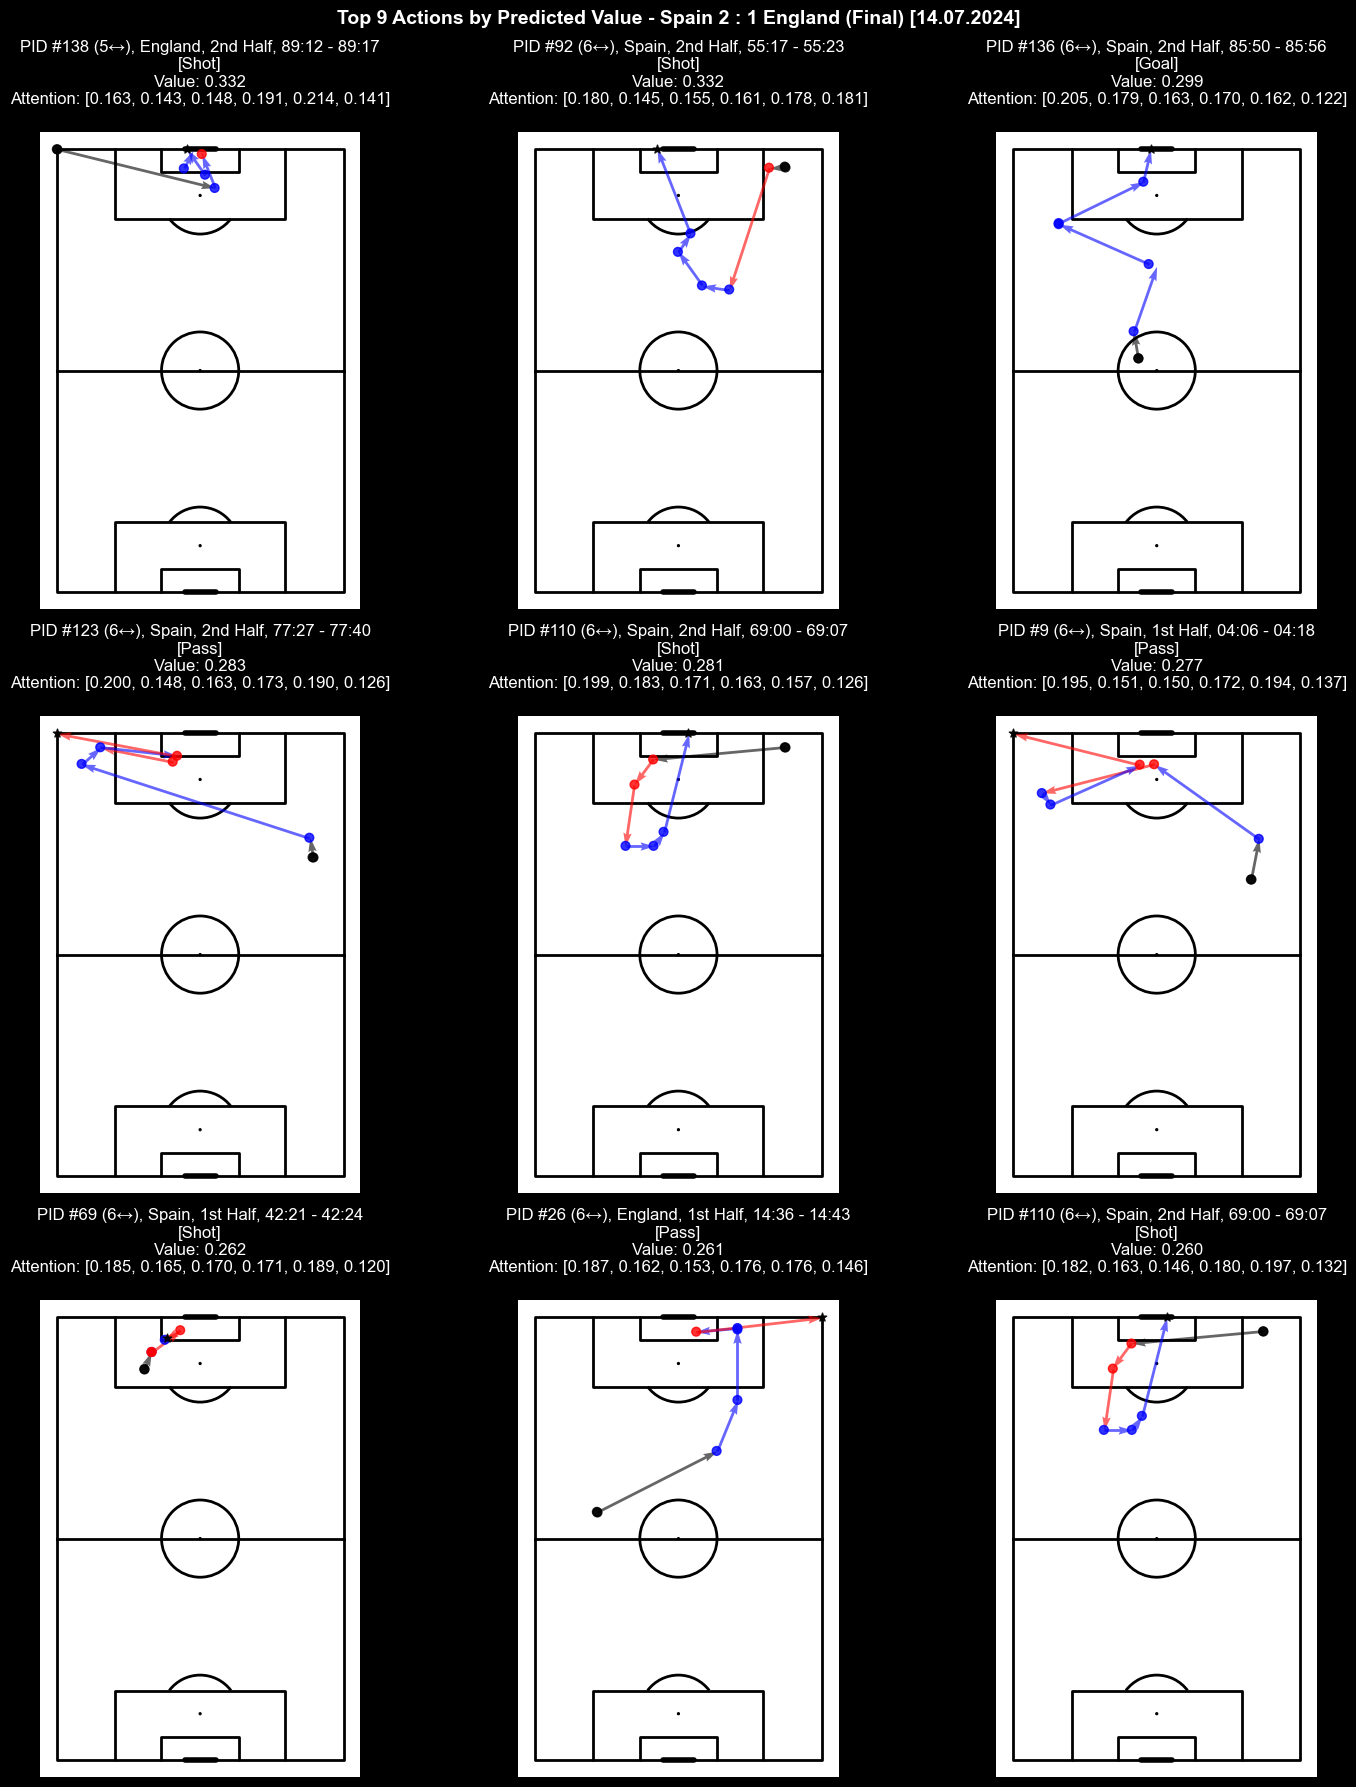

In [22]:
visualize_top_possessions(selected_match, selected_events, p, predicted_values_final, attention_weights_final, 9, config.SEQUENCE_LENGTH)
plt.savefig(f"models/{MODEL_TYPE}/top_possessions_final.png", dpi=300)
